# Download Sentinel-2 via the NCI Datacube

Fetch Sentinel-2 surface-reflectance imagery directly from the
[NCI](https://nci.org.au/) datacube using ``datacube`` and ``dea_tools``.

**Requirements**: must be run inside the DEA/NCI sandbox or on Gadi with
the ``shelterbelts`` conda environment loaded.

In [1]:
import pickle

import datacube
import matplotlib.pyplot as plt
import numpy as np
import rioxarray as rxr

from shelterbelts.classifications.sentinel_nci import define_query_range, load_and_process_data, download_ds2
from shelterbelts.utils.filepaths import get_filename

## Configure the area and date range

We derive the bounding box from the binary-tree-cover tif and convert to
EPSG:4326 lat/lon ranges for the datacube query.

In [2]:
tif = get_filename('g2_26729_binary_tree_cover_10m.tiff')
da = rxr.open_rasterio(tif).isel(band=0).drop_vars('band')
bbox = da.rio.reproject('EPSG:4326').rio.bounds()
print(f"Bounding box (EPSG:4326): {bbox}")

start_date = "2020-01-01"
end_date   = "2020-04-01"

lat_range = (bbox[1], bbox[3])
lon_range = (bbox[0], bbox[2])

Bounding box (EPSG:4326): (148.41382213064517, -34.38722232632411, 148.43590240126792, -34.36893866331976)


## Build the datacube query

In [3]:
query = define_query_range(lat_range, lon_range, time_range=(start_date, end_date))
query

{'y': (-34.38722232632411, -34.36893866331976),
 'x': (148.41382213064517, 148.43590240126792),
 'time': ('2020-01-01', '2020-04-01'),
 'resolution': (-10, 10),
 'crs': 'epsg:4326',
 'output_crs': 'epsg:6933',
 'group_by': 'solar_day'}

## Load the imagery

``load_and_process_data`` calls ``load_ard`` with a 90 % good-data threshold
and pixel-level cloud masking via ``s2cloudless``.

In [4]:
%%time
dc = datacube.Datacube(app='demo_sentinel_nci')
ds = load_and_process_data(dc, query)
ds

CPU times: user 13.5 s, sys: 3.86 s, total: 17.4 s
Wall time: 15.5 s


<xarray.Dataset>
Dimensions:           (time: 19, y: 194, x: 214)
Coordinates:
  * time              (time) datetime64[ns] 2020-01-03T00:16:07.668999 ... 20...
  * y                 (y) float64 -4.132e+06 -4.132e+06 ... -4.134e+06
  * x                 (x) float64 1.432e+07 1.432e+07 ... 1.432e+07 1.432e+07
    spatial_ref       int32 6933
Data variables:
    nbart_blue        (time, y, x) float32 605.0 615.0 624.0 ... 702.0 702.0
    nbart_green       (time, y, x) float32 706.0 743.0 ... 1.042e+03 1.042e+03
    nbart_red         (time, y, x) float32 879.0 876.0 ... 1.157e+03 1.157e+03
    nbart_red_edge_1  (time, y, x) float32 1.224e+03 1.28e+03 ... 1.747e+03
    nbart_red_edge_2  (time, y, x) float32 1.723e+03 1.843e+03 ... 3.13e+03
    nbart_red_edge_3  (time, y, x) float32 1.903e+03 2.054e+03 ... 3.511e+03
    nbart_nir_1       (time, y, x) float32 1.85e+03 2.233e+03 ... 3.665e+03
    nbart_nir_2       (time, y, x) float32 2.167e+03 2.372e+03 ... 3.867e+03
    nbart_swir_2      (time, y, x) float32 2.333e+03 2.345e+03 ... 3.78e+03
    nbart_swir_3      (time, y, x) float32 1.48e+03 1.468e+03 ... 2.494e+03
Attributes:
    crs:           epsg:6933
    grid_mapping:  spatial_ref

## Example Visualisation

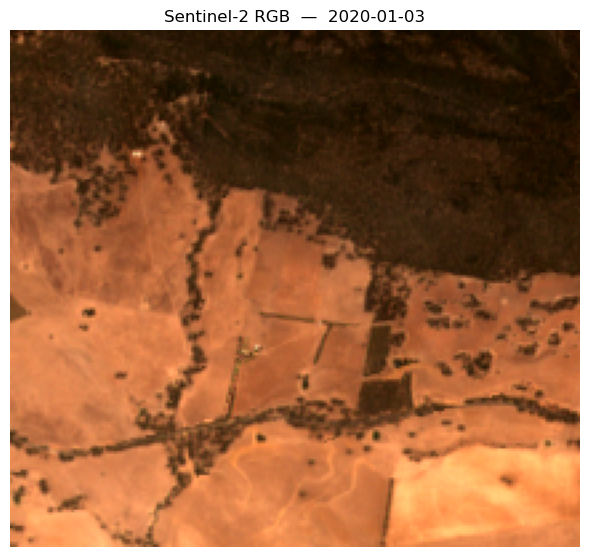

In [5]:
date_idx = 0
date_str = str(ds.time.values[date_idx])[:10]

red   = ds['nbart_red'].isel(time=date_idx).values.astype(float)
green = ds['nbart_green'].isel(time=date_idx).values.astype(float)
blue  = ds['nbart_blue'].isel(time=date_idx).values.astype(float)

# Stack and normalise to [0, 1] using a simple percentile stretch
rgb = np.stack([red, green, blue], axis=-1)
lo, hi = np.nanpercentile(rgb, 2), np.nanpercentile(rgb, 98)
rgb = np.clip((rgb - lo) / (hi - lo), 0, 1)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(rgb)
ax.set_title(f"Sentinel-2 RGB  —  {date_str}")
ax.axis('off')
plt.tight_layout()
plt.show()

## Save to disk

``download_ds2`` wraps the query, load, and pickle steps above.

In [6]:
%%time
ds = download_ds2(tif, start_date=start_date, end_date=end_date, outdir='.')

Saved ./g2_26729_binary_tree_cover_10m_ds2_2020.pkl
CPU times: user 14.2 s, sys: 2.27 s, total: 16.5 s
Wall time: 12.8 s
